In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
api_key = os.getenv("OPENROUTER_API_KEY")

In [22]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-oss-120b:free",  
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key
)

In [23]:
llm.model

'openai/gpt-oss-120b:free'

In [24]:
## Node Functionality
def chatbot(state:State):
    return  {"messages":[llm.invoke(state['messages'])]}

In [25]:
graph_builder = StateGraph(State)

#adding node
graph_builder.add_node('llmchatbot', chatbot)
#adding edges
graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge("llmchatbot",END)

#compile the graph
graph=graph_builder.compile()

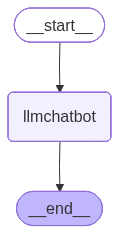

In [26]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [27]:
response=graph.invoke({"messages":"Hi"})

In [28]:
response["messages"][-1].content

'Hello! How can I assist you today?'

In [29]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thank you for asking. How can I help you today?


In [40]:
print(os.getenv("TAVILY_API_KEY"))

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


In [41]:
import os

os.environ["TAVILY_API_KEY"] 

from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

print(tool.invoke("what is langgraph"))

{'query': 'what is langgraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph', 'title': 'What is LangGraph - GeeksforGeeks', 'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to create a b

In [42]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [43]:
tools=[tool,multiply]

In [44]:
llm_with_tool=llm.bind_tools(tools)

In [45]:
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10', 'langchain-openai': '1.3.2'}}, output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x0000011DF5C28A50>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000011DF5C28E10>, root_client=<openai.OpenAI object at 0x0000011DF5C291D0>, root_async_client=<openai.AsyncOpenAI object at 0x0000011DF5C28910>, model_name='openai/gpt-oss-120b:free', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', openai_proxy=None, stream_chunk_timeout=120.0), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, d

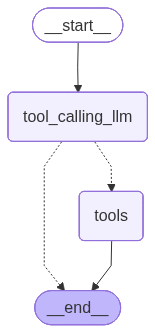

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


def tool_calling_llm(state:State):
    return {"messages":llm_with_tool.invoke(state['messages'])}

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges('tool_calling_llm',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)

builder.add_edge('tools',END)
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [48]:
response['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.7511561, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "IN TODAY’S NEWSLETTER:\\n\\n- Jeff Bezos predicts AI will create a labor shortage, not replace human workers across the economy\\n\\n- OpenAI faces multistate investigation into data handling and chatbot behavior\\n\\n- AI-designed \'universal vaccine\' passes first human clinical trial, could prevent future pandemics\\n\\nWORK IN PROGRESS: Amazon founder Jeff Bezos said the rise of artificial intelligence (AI) won\'t lead to the replacement of humans in the workforce and will instead create labor shortages.\\n\\nSam Altman, chief executive officer of OpenAI, during a panel session on day three of the World Economic Forum (WEF) in Davos, Switzerlan

In [49]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-9c77a0717295c02b)
 Call ID: chatcmpl-tool-9c77a0717295c02b
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-bezos-predicts-labor-shortage", "title": "Fox News AI Newsletter: Bezos predicts labor shortage - Fox News", "score": 0.7511561, "published_date": "Fri, 19 Jun 2026 13:11:08 GMT", "content": "IN TODAY’S NEWSLETTER:\n\n- Jeff Bezos predicts AI will create a labor shortage, not replace human workers across the economy\n\n- OpenAI faces multistate investigat

In [50]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-bcde3aa18a1fd810)
 Call ID: chatcmpl-tool-bcde3aa18a1fd810
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [51]:
sponse=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-bcde3aa18a1fd810)
 Call ID: chatcmpl-tool-bcde3aa18a1fd810
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


### **ReAct Agent Architecture**

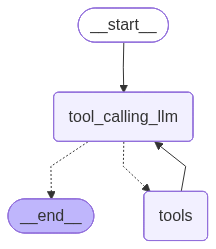

In [52]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node('tools',ToolNode(tools))

builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges('tool_calling_llm',
                            tools_condition
)

builder.add_edge("tools","tool_calling_llm")
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-838e2afd7421b0c0)
 Call ID: chatcmpl-tool-838e2afd7421b0c0
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    topic: news
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://michaelparekh.substack.com/p/the-four-corners-and-key-pieces-of", "title": "The Four Corners & Key Pieces of 2026 AI Chess Board Clearer. ARD #93 - AI: Reset to Zero", "score": 0.6944897, "published_date": "Tue, 09 Jun 2026 20:02:51 GMT", "content": "AI Ramblings Daily on AI-RTZ is here to think through AI and reset. Together.\n\nTod

### **Build A Basic Chatbot With Langgraph(GRAPH API)**

#### ***without memory***

In [54]:
response=graph.invoke({"messages":"Hello my name is Hridayansh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Hridayansh
================================== Ai Message ==================================

Hello Hridayansh! Nice to meet you. How can I assist you today?


In [55]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!


#### ***with memory***

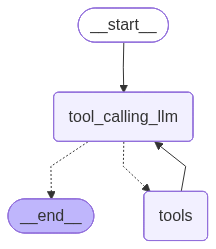

In [57]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver #this will be used for memory


memory = MemorySaver() #initialize checkpointer

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [58]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Hridayansh"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Hridayansh', additional_kwargs={}, response_metadata={}, id='e0a8bfa9-df6f-45ac-9d54-d5ca9865bf12'),
  AIMessage(content='Nice to meet you, Hridayansh! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 1301, 'total_tokens': 1333, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 5, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 64, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b:free', 'system_fingerprint': None, 'id': 'gen-1782078238-QueimNqVmhQIUOZigsDj', 'finish_reason': 'stop', 'logprobs': None}, id='lc_ru

In [59]:
response['messages'][-1].content

'Nice to meet you, Hridayansh! How can I help you today?'

In [60]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Hridayansh.


In [61]:
response=graph.invoke({"messages":"Hey do you remember my name"},config=config)

print(response['messages'][-1].content)

Yes, you told me your name is Hridayansh. Is there anything else you’d like to chat about?
